# ECCOv4 Volume Budget Closure Test

This notebook tests the volume budget closure for ECCO output.

**Inputs:**
- MDS files (data/meta) for UVELMASS, VVELMASS, ETAN, OR
- NetCDF files with these variables
- Optional: SHIfwFlx, ICFfwFlx (ice shelf and ice front freshwater fluxes)

**Outputs:**
- Global volume conservation test: PASS/FAIL
- Random point tests: PASS/FAIL for individual grid cells and columns

**Budget Equation:**
$$\frac{\partial \eta}{\partial t} = \frac{\text{oceFWflx}}{\rho_0} + \nabla_h \cdot (\text{UVELMASS}, \text{VVELMASS}) + \frac{\text{SHIfwFlx + ICFfwFlx}}{\rho_0}$$

The last term (ice shelf/ice front fluxes) is optional and included if the data exists.

## 1. Configuration and Imports

In [1]:
import numpy as np
import xarray as xr
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import ecco_v4_py as ecco

# Reference density (kg/m^3)
rhoconst = 1029.0

# Test thresholds (ratio-based: RMSE(residual) / RMSE(term))
GLOBAL_THRESHOLD = 1e-4   # For global mean: ratio < 1e-4
POINT_THRESHOLD = 1e-3    # For individual points: ratio < 1e-3
N_RANDOM_POINTS = 10      # Number of random points to test

# Point selection criteria
N_ARCTIC_POINTS = 1       # Number of points from Tile 7 (Arctic)
N_ICE_SHELF_POINTS = 2    # Number of points with large SHIfwFlx (if available)

## 2. Input Configuration

Set `input_type` to either `'mds'` or `'netcdf'`

In [2]:
# ========== USER CONFIGURATION ==========

# Choose input type: 'mds' or 'netcdf'
input_type = 'mds'  # or 'netcdf'

# Grid directory (required for both MDS and NetCDF)
grid_dir = '/mnt/extraid/ifraid8/data07/owang/Ecco_data/v4/JPL/input/grid/V4r5/'

if input_type == 'mds':
    # MDS file configuration
    mds_base_dir = '/ecco_nfs_1/owang/projects/ECCO/llc90/v4/release6/r102/r102g/run.v4_rls6.102g.iter47/'
    mds_snap_dir = mds_base_dir + 'diags_inst/'
    mds_mean_dir = mds_base_dir + 'diags_monthly/'
    
    # Variable names in MDS files
    snap_vars = ['ETAN']  # Snapshot variables
    # Required mean variables
    mean_vars_required = ['oceFWflx', 'UVELMASS', 'VVELMASS', 'WVELMASS']
    # Optional ice shelf/ice front variables
    mean_vars_optional = ['SHIfwFlx', 'ICFfwFlx']
    
elif input_type == 'netcdf':
    # NetCDF file configuration
    snap_file = '/path/to/monthly_snapshots.nc'  # File with ETAN snapshots
    mean_file = '/path/to/monthly_means.nc'      # File with UVELMASS, VVELMASS, oceFWflx
else:
    raise ValueError("input_type must be 'mds' or 'netcdf'")

# ========================================

## 3. Load Grid

In [3]:
# Load ECCO grid
ecco_grid = ecco.load_ecco_grid_nc(grid_dir + 'nctiles_grid_xmitgcm/', 'ECCO-GRID.nc')
ecco_xgcm_grid = ecco.get_llc_grid(ecco_grid)

print(f"Grid loaded successfully")
print(f"Grid dimensions: {ecco_grid.dims}")

Grid loaded successfully
Grid dimensions: FrozenMappingWarningOnValuesAccess({'tile': 13, 'j': 90, 'i': 90, 'j_g': 90, 'i_g': 90, 'k_p1': 51, 'k': 50, 'k_u': 50, 'k_l': 50})


## 4. Load Data

This section handles both MDS and NetCDF inputs and produces standardized xarray DataArrays.
It will automatically detect and load ice shelf/ice front fluxes if available.

In [4]:
# Track which variables are available
has_SHIfwFlx = False
has_ICFfwFlx = False

if input_type == 'mds':
    print("Loading data from MDS files...")
    
    # Load snapshots
    for ivar, var_snap in enumerate(snap_vars):
        snap_path = mds_snap_dir + var_snap + '_snap'
        snap_data = ecco.load_ecco_vars_from_mds(
            snap_path, grid_dir,
            mds_files=var_snap + '_snap'
        ).reset_coords(drop=True)
        
        if ivar == 0:
            ecco_monthly_snaps = snap_data.copy(deep=True)
        else:
            ecco_monthly_snaps = xr.merge([ecco_monthly_snaps, snap_data])
    
    # Load required monthly means
    for ivar, var in enumerate(mean_vars_required):
        mean_path = mds_mean_dir + var + '_mon_mean'
        mean_data = ecco.load_ecco_vars_from_mds(
            mean_path, grid_dir,
            mds_files=var + '_mon_mean'
        ).reset_coords(drop=True)
        
        if ivar == 0:
            ecco_monthly_mean = mean_data.copy(deep=True)
        else:
            ecco_monthly_mean = xr.merge([ecco_monthly_mean, mean_data])
    
    # Try to load optional ice shelf/ice front variables
    for var in mean_vars_optional:
        mean_path = mds_mean_dir + var + '_mon_mean'
        try:
            # Check if directory exists (MDS files are organized in subdirectories)
            from pathlib import Path
            if Path(mean_path).exists():
                mean_data = ecco.load_ecco_vars_from_mds(
                    mean_path, grid_dir,
                    mds_files=var + '_mon_mean'
                ).reset_coords(drop=True)
                ecco_monthly_mean = xr.merge([ecco_monthly_mean, mean_data])
                
                if var == 'SHIfwFlx':
                    has_SHIfwFlx = True
                    print(f"  ✓ Found {var}")
                elif var == 'ICFfwFlx':
                    has_ICFfwFlx = True
                    print(f"  ✓ Found {var}")
            else:
                print(f"  ⚠ {var} not found (optional - will skip)")
        except Exception as e:
            print(f"  ⚠ Could not load {var} (optional - will skip): {e}")
    
    print(f"\nLoaded {len(ecco_monthly_snaps.time)} snapshots")
    print(f"Loaded {len(ecco_monthly_mean.time)} monthly means")
    
elif input_type == 'netcdf':
    print("Loading data from NetCDF files...")
    
    # Load snapshots
    ecco_monthly_snaps = xr.open_dataset(snap_file)
    
    # Load monthly means
    ecco_monthly_mean = xr.open_dataset(mean_file)
    
    # Check for optional ice shelf/ice front variables
    if 'SHIfwFlx' in ecco_monthly_mean:
        has_SHIfwFlx = True
        print("  ✓ Found SHIfwFlx")
    else:
        print("  ⚠ SHIfwFlx not found (optional - will skip)")
    
    if 'ICFfwFlx' in ecco_monthly_mean:
        has_ICFfwFlx = True
        print("  ✓ Found ICFfwFlx")
    else:
        print("  ⚠ ICFfwFlx not found (optional - will skip)")
    
    print(f"\nLoaded {len(ecco_monthly_snaps.time)} snapshots")
    print(f"Loaded {len(ecco_monthly_mean.time)} monthly means")

# CRITICAL TIME ALIGNMENT:
# Snapshots bookend monthly means. If we have N snapshots, we have N-1 monthly means.
# Snapshot[0] is at END of month 0, Snapshot[1] is at END of month 1, etc.
# Monthly_mean[0] is the MEAN of month 0 (between Snapshot[-1] and Snapshot[0] if continuing from previous period)
# 
# For budget closure: dETAN/dt between Snapshot[i] and Snapshot[i+1] should match Monthly_mean[i+1]
# Therefore: DROP THE FIRST monthly mean record, not the last!
#
# Example with 265 snapshots:
#   Snapshots: indices 0-264 (265 total)
#   Monthly means before: indices 0-264 (265 total) 
#   Tendency: Snapshot[1] - Snapshot[0], Snapshot[2] - Snapshot[1], ..., Snapshot[264] - Snapshot[263] (264 values)
#   Monthly means after: indices 1-264 (264 total)
#   This way: Tendency[i] corresponds to Monthly_mean[i+1]

num_months = len(ecco_monthly_snaps.time)

# Drop FIRST record from monthly means (not last!)
ecco_monthly_mean = ecco_monthly_mean.isel(time=np.arange(1, num_months))

print(f"\n{'='*70}")
print("TIME ALIGNMENT CHECK")
print(f"{'='*70}")
print(f"Number of snapshots:     {num_months}")
print(f"Number of monthly means: {len(ecco_monthly_mean.time)} (after dropping first record)")
print(f"Number of tendencies:    {num_months - 1} (from snapshot differences)")
print(f"\nSnapshot times:     {ecco_monthly_snaps.time.values[0]} to {ecco_monthly_snaps.time.values[-1]}")
print(f"Monthly mean times: {ecco_monthly_mean.time.values[0]} to {ecco_monthly_mean.time.values[-1]}")
print(f"\nFirst tendency will be: Snapshot[1] - Snapshot[0]")
print(f"                        = {ecco_monthly_snaps.time.values[1]} - {ecco_monthly_snaps.time.values[0]}")
print(f"Matched with monthly mean at: {ecco_monthly_mean.time.values[0]}")
print(f"{'='*70}")

print(f"\nIce shelf/ice front fluxes: {'INCLUDED' if (has_SHIfwFlx or has_ICFfwFlx) else 'NOT INCLUDED'}")
if has_SHIfwFlx or has_ICFfwFlx:
    print(f"  - SHIfwFlx: {'YES' if has_SHIfwFlx else 'NO'}")
    print(f"  - ICFfwFlx: {'YES' if has_ICFfwFlx else 'NO'}")

Loading data from MDS files...
  ✓ Found SHIfwFlx
  ✓ Found ICFfwFlx

Loaded 7 snapshots
Loaded 7 monthly means

TIME ALIGNMENT CHECK
Number of snapshots:     7
Number of monthly means: 6 (after dropping first record)
Number of tendencies:    6 (from snapshot differences)

Snapshot times:     1992-02-01T00:00:00.000000000 to 1992-08-01T00:00:00.000000000
Monthly mean times: 1992-03-01T00:00:00.000000000 to 1992-08-01T00:00:00.000000000

First tendency will be: Snapshot[1] - Snapshot[0]
                        = 1992-03-01T00:00:00.000000000 - 1992-02-01T00:00:00.000000000
Matched with monthly mean at: 1992-03-01T00:00:00.000000000

Ice shelf/ice front fluxes: INCLUDED
  - SHIfwFlx: YES
  - ICFfwFlx: YES


## 5. Calculate LHS: ETAN Time Tendency

$$G_{\text{total tendency}} = \frac{\partial \eta}{\partial t}$$

In [5]:
# Calculate ETAN tendency between snapshots
G_total_tendency_month = (
    ecco_monthly_snaps.ETAN.isel(time=range(1, num_months)).values - 
    ecco_monthly_snaps.ETAN.isel(time=range(0, num_months-1)).values
)

# Convert to DataArray
G_total_tendency_month = xr.DataArray(
    G_total_tendency_month,
    coords={
        'time': ecco_monthly_mean.time.values,
        'tile': ecco_monthly_snaps.tile.values,
        'j': ecco_monthly_snaps.j.values,
        'i': ecco_monthly_snaps.i.values
    },
    dims=['time', 'tile', 'j', 'i']
)

# Calculate seconds per month
secs_per_month = (
    ecco_monthly_snaps.time[1:].values - 
    ecco_monthly_snaps.time[0:-1].values
).astype('float') / 1e9  # Convert ns to seconds

secs_per_month = xr.DataArray(
    secs_per_month,
    coords={'time': ecco_monthly_mean.time.values},
    dims='time'
)

# Convert to m/s
G_total_tendency = G_total_tendency_month / secs_per_month

print(f"LHS (dETA/dt) calculated: shape {G_total_tendency.shape}")
print(f"Time range spans {secs_per_month.sum().values / (3600*24*365):.2f} years")

LHS (dETA/dt) calculated: shape (6, 13, 90, 90)
Time range spans 0.50 years


## 6. Calculate RHS: Surface Fluxes

$$G_{\text{surface fluxes}} = \frac{\text{oceFWflx}}{\rho_0}$$

In [6]:
# Surface freshwater flux contribution
G_surf_fluxes = ecco_monthly_mean.oceFWflx / rhoconst

print(f"RHS surface fluxes calculated: shape {G_surf_fluxes.shape}")

RHS surface fluxes calculated: shape (6, 13, 90, 90)


## 7. Calculate RHS: Horizontal Volume Flux Divergence

$$G_{\text{horiz divergence}} = \nabla_h \cdot (\text{UVELMASS}, \text{VVELMASS})$$

In [7]:
# Define the custom diff_2d_flux_llc90 function for LLC90 grid topology
def diff_2d_flux_llc90(flux_vector_dict):
    """
    A function that differences flux variables on the llc90 grid.
    Can be used in place of xgcm's diff_2d_vector.
    """
    u_flux = flux_vector_dict['X']
    v_flux = flux_vector_dict['Y']
    
    u_flux_padded = u_flux.pad(pad_width={'i_g':(0,1)},mode='constant',constant_values=np.nan)\
                            .chunk({'i_g':u_flux.sizes['i_g']+1})
    v_flux_padded = v_flux.pad(pad_width={'j_g':(0,1)},mode='constant',constant_values=np.nan)\
                            .chunk({'j_g':v_flux.sizes['j_g']+1})
    
    def da_replace_at_indices(da,indexing_dict,replace_values):
        # replace values in xarray DataArray using locations specified by indexing_dict
        array_data = da.data
        indexing_dict_bynum = {}
        for axis,dim in enumerate(da.dims):
            if dim in indexing_dict.keys():
                indexing_dict_bynum = {**indexing_dict_bynum,**{axis:indexing_dict[dim]}}
        ndims = len(array_data.shape)
        indexing_list = [':']*ndims
        for axis in indexing_dict_bynum.keys():
            indexing_list[axis] = indexing_dict_bynum[axis]
        indexing_str = ",".join(indexing_list)

        # using exec isn't ideal, but this works for both NumPy and Dask arrays
        exec('array_data['+indexing_str+'] = replace_values')        
        
        return da
    
    # u flux padding
    for tile in range(0,3):
        u_flux_padded = da_replace_at_indices(u_flux_padded,{'tile':str(tile),'i_g':'-1'},\
                                              u_flux.isel(tile=tile+3,i_g=0).data)
    for tile in range(3,6):
        u_flux_padded = da_replace_at_indices(u_flux_padded,{'tile':str(tile),'i_g':'-1'},\
                                              v_flux.isel(tile=12-tile,j_g=0,i=slice(None,None,-1)).data)
    u_flux_padded = da_replace_at_indices(u_flux_padded,{'tile':'6','i_g':'-1'},\
                                          u_flux.isel(tile=7,i_g=0).data)
    for tile in range(7,9):
        u_flux_padded = da_replace_at_indices(u_flux_padded,{'tile':str(tile),'i_g':'-1'},\
                                              u_flux.isel(tile=tile+1,i_g=0).data)
    for tile in range(10,12):
        u_flux_padded = da_replace_at_indices(u_flux_padded,{'tile':str(tile),'i_g':'-1'},\
                                              u_flux.isel(tile=tile+1,i_g=0).data)
        
    # v flux padding
    for tile in range(0,2):
        v_flux_padded = da_replace_at_indices(v_flux_padded,{'tile':str(tile),'j_g':'-1'},\
                                              v_flux.isel(tile=tile+1,j_g=0).data)
    v_flux_padded = da_replace_at_indices(v_flux_padded,{'tile':'2','j_g':'-1'},\
                                          u_flux.isel(tile=6,j=slice(None,None,-1),i_g=0).data)
    for tile in range(3,6):
        v_flux_padded = da_replace_at_indices(v_flux_padded,{'tile':str(tile),'j_g':'-1'},\
                                              v_flux.isel(tile=tile+1,j_g=0).data)
    v_flux_padded = da_replace_at_indices(v_flux_padded,{'tile':'6','j_g':'-1'},\
                                          u_flux.isel(tile=10,j=slice(None,None,-1),i_g=0).data)
    for tile in range(7,10):
        v_flux_padded = da_replace_at_indices(v_flux_padded,{'tile':str(tile),'j_g':'-1'},\
                                              v_flux.isel(tile=tile+3,j_g=0).data)
    for tile in range(10,13):
        v_flux_padded = da_replace_at_indices(v_flux_padded,{'tile':str(tile),'j_g':'-1'},\
                                              u_flux.isel(tile=12-tile,j=slice(None,None,-1),i_g=0).data)
    
    # take differences
    diff_u_flux = u_flux_padded.diff('i_g')
    diff_v_flux = v_flux_padded.diff('j_g')
    
    # include coordinates of input DataArrays and correct dimension/coordinate names
    diff_u_flux = diff_u_flux.assign_coords(u_flux.coords).rename({'i_g':'i'})
    diff_v_flux = diff_v_flux.assign_coords(v_flux.coords).rename({'j_g':'j'})

    diff_flux_vector_dict = {'X':diff_u_flux,'Y':diff_v_flux}
    
    return diff_flux_vector_dict

# Volumetric transports (m^3/s)
vol_transport_x = ecco_monthly_mean.UVELMASS * ecco_grid.dyG * ecco_grid.drF
vol_transport_y = ecco_monthly_mean.VVELMASS * ecco_grid.dxG * ecco_grid.drF

# Set land values to zero
vol_transport_x = vol_transport_x.fillna(0)
vol_transport_y = vol_transport_y.fillna(0)

# Calculate horizontal divergence using custom LLC90 function
print("Calculating horizontal divergence...")

# Difference of horizontal transports in x and y directions
vol_flux_diff = diff_2d_flux_llc90({'X': vol_transport_x, 'Y': vol_transport_y})

# Volume flux divergence into each grid cell, m^3 / s
vol_horiz_divergence = (vol_flux_diff['X'] + vol_flux_diff['Y'])

# Restore time coordinate to DataArray (lost in diff operation)
vol_horiz_divergence = vol_horiz_divergence.assign_coords({'time': vol_transport_x.time.data})

# Convert to eta tendency (m/s) at each depth
# IMPORTANT: A positive DIVERGENCE leads to negative eta tendency, hence the negative sign
G_vol_horiz_divergence = -vol_horiz_divergence / ecco_grid.rA

# Depth-integrate
G_vol_horiz_divergence_depth_integrated = G_vol_horiz_divergence.sum('k').compute()

print(f"RHS horizontal divergence calculated: shape {G_vol_horiz_divergence_depth_integrated.shape}")

Calculating horizontal divergence...
RHS horizontal divergence calculated: shape (6, 13, 90, 90)


## 8. Calculate RHS: Ice Shelf and Ice Front Freshwater Fluxes (if available)

$$G_{\text{ice shelf/ice front}} = \frac{\text{SHIfwFlx + ICFfwFlx}}{\rho_0}$$

This section will be skipped if SHIfwFlx and ICFfwFlx are not available.

In [8]:
# Initialize to zero
G_shiicf_fluxes_depth_integrated = None

if has_SHIfwFlx or has_ICFfwFlx:
    print("Processing ice shelf and ice front freshwater fluxes...")
    
    # Create 3D ice-shelf mask
    # This identifies ice-ocean interface cells
    print("  Creating 3D ice-shelf mask...")
    mskC = ecco_grid.hFacC.copy(deep=True).load()
    mskC.values[mskC.values > 0] = 1  # Ocean = 1, land = 0
    
    # Shift mask down by one level
    mskC_shifted_down = mskC.shift(k=1)
    mskC_shifted_down.values[0, :, :, :] = np.copy(mskC.values[0, :, :, :])
    
    # Ice-ocean interface: ocean cells with ice/land above
    mskicf = mskC - mskC_shifted_down
    mskicf.values[mskicf.values < -1e-4] = 0
    
    # Construct 3D freshwater forcing field
    print("  Constructing 3D freshwater flux field...")
    shiicf_fw_3d = 0.0
    
    if has_SHIfwFlx:
        # Map 2D ice-shelf flux onto ice-ocean interface cells
        shi_fw_3d = mskicf * ecco_monthly_mean.SHIfwFlx
        shiicf_fw_3d = shiicf_fw_3d + shi_fw_3d
        print("    ✓ Added SHIfwFlx")
    
    if has_ICFfwFlx:
        # Add 3D ice-front flux
        shiicf_fw_3d = shiicf_fw_3d + ecco_monthly_mean.ICFfwFlx
        print("    ✓ Added ICFfwFlx")

    # Revert the sign of shiicf_fw_3d so positve is to add water to the ocean
    shiicf_fw_3d = -shiicf_fw_3d
    
    # Convert to volume tendency
    G_shiicf_fluxes = shiicf_fw_3d / rhoconst
    
    # Depth-integrate
    G_shiicf_fluxes_depth_integrated = G_shiicf_fluxes.sum('k').compute()
    
    print(f"  Ice shelf/ice front fluxes calculated: shape {G_shiicf_fluxes_depth_integrated.shape}")
    
else:
    print("No ice shelf/ice front fluxes to process (variables not found)")
    # Create a zero field with the same shape as other terms
    G_shiicf_fluxes_depth_integrated = xr.zeros_like(G_surf_fluxes)

Processing ice shelf and ice front freshwater fluxes...
  Creating 3D ice-shelf mask...
  Constructing 3D freshwater flux field...
    ✓ Added SHIfwFlx
    ✓ Added ICFfwFlx
  Ice shelf/ice front fluxes calculated: shape (13, 90, 90, 6)


## 9. Volume Budget Closure Test

The budget should close:
$$\frac{\partial \eta}{\partial t} - G_{\text{surface fluxes}} - G_{\text{horiz divergence}} - G_{\text{ice shelf/ice front}} \approx 0$$

In [9]:
# Calculate residual
residual = (
    G_total_tendency - 
    G_surf_fluxes - 
    G_vol_horiz_divergence_depth_integrated - 
    G_shiicf_fluxes_depth_integrated
)

print("Volume budget residual calculated")
print(f"Residual shape: {residual.shape}")
if has_SHIfwFlx or has_ICFfwFlx:
    print("(includes ice shelf/ice front contributions)")
else:
    print("(no ice shelf/ice front contributions)")

Volume budget residual calculated
Residual shape: (6, 13, 90, 90)
(includes ice shelf/ice front contributions)


## 10. Test 1: Global Volume Conservation

In [10]:
# Mask for ocean points
area_masked = ecco_grid.rA.where(ecco_grid.hFacC.isel(k=0) > 0).compute()
area_masked_sum = area_masked.sum(dim=('i', 'j', 'tile')).values

# Global area-weighted mean residual
global_residual = (residual * area_masked).sum(dim=('i', 'j', 'tile')) / area_masked_sum
global_residual = global_residual.compute()

# Calculate RMSE of residual
global_residual_rmse = float(np.sqrt((global_residual**2).mean()))

# Calculate RMSE of LHS (total tendency)
global_lhs = (G_total_tendency * area_masked).sum(dim=('i', 'j', 'tile')) / area_masked_sum
global_lhs = global_lhs.compute()
global_lhs_rmse = float(np.sqrt((global_lhs**2).mean()))

# Calculate relative error ratio
global_ratio = global_residual_rmse / global_lhs_rmse if global_lhs_rmse > 0 else np.inf

# Statistics
global_residual_mean = float(global_residual.mean())
global_residual_std = float(global_residual.std())
global_residual_max = float(np.abs(global_residual).max())

print("\n" + "="*70)
print("TEST 1: GLOBAL VOLUME CONSERVATION")
print("="*70)
print(f"Global mean residual: {global_residual_mean:.3e} m/s")
print(f"Global std residual:  {global_residual_std:.3e} m/s")
print(f"Global max |residual|: {global_residual_max:.3e} m/s")
print(f"\nRMSE(residual):       {global_residual_rmse:.3e} m/s")
print(f"RMSE(LHS dETA/dt):    {global_lhs_rmse:.3e} m/s")
print(f"Relative ratio:       {global_ratio:.3e}")
print(f"Threshold:            {GLOBAL_THRESHOLD:.3e}")

# Pass/Fail based on ratio
global_test_pass = global_ratio < GLOBAL_THRESHOLD

if global_test_pass:
    print(f"\n✓ PASS: Global volume budget closes to within threshold")
    print(f"  Ratio is {global_ratio/GLOBAL_THRESHOLD:.2f}x the threshold")
else:
    print(f"\n✗ FAIL: Global volume budget exceeds threshold")
    print(f"  Ratio is {global_ratio/GLOBAL_THRESHOLD:.1f}x the threshold")

print("="*70)


TEST 1: GLOBAL VOLUME CONSERVATION
Global mean residual: -1.473e-15 m/s
Global std residual:  2.865e-15 m/s
Global max |residual|: 6.907e-15 m/s

RMSE(residual):       3.221e-15 m/s
RMSE(LHS dETA/dt):    2.431e-09 m/s
Relative ratio:       1.325e-06
Threshold:            1.000e-04

✓ PASS: Global volume budget closes to within threshold
  Ratio is 0.01x the threshold


## 11. Test 2: Random Point Tests

In [11]:
# Find valid ocean points
ocean_mask = ecco_grid.hFacC.isel(k=0) > 0
valid_tiles, valid_js, valid_is = np.where(ocean_mask.values)

# Initialize list to track selected points
selected_indices = []
selected_labels = []

# 1. Select one point from Tile 7 (Arctic)
print("\nSelecting special points...")
tile7_mask = valid_tiles == 7
if tile7_mask.any():
    tile7_indices = np.where(tile7_mask)[0]
    np.random.seed(42)
    arctic_idx = np.random.choice(tile7_indices, size=1)[0]
    selected_indices.append(arctic_idx)
    selected_labels.append("Arctic (Tile 7)")
    print(f"  ✓ Selected 1 Arctic point from Tile 7")
else:
    print(f"  ⚠ No points found in Tile 7")

# 2. Select points with large SHIfwFlx (if available)
if has_SHIfwFlx:
    # Calculate mean absolute SHIfwFlx at each point
    shicf_mean_abs = np.abs(G_shiicf_fluxes_depth_integrated).mean(dim='time').compute()
    
    # Flatten to 1D array matching valid points
    shicf_values = []
    for idx in range(len(valid_tiles)):
        tile = valid_tiles[idx]
        j = valid_js[idx]
        i = valid_is[idx]
        shicf_values.append(float(shicf_mean_abs.isel(tile=tile, j=j, i=i)))
    
    shicf_values = np.array(shicf_values)
    
    # Find indices with largest SHIfwFlx (excluding already selected points)
    available_mask = np.ones(len(valid_tiles), dtype=bool)
    available_mask[selected_indices] = False
    
    # Get top N_ICE_SHELF_POINTS
    available_shicf = shicf_values.copy()
    available_shicf[~available_mask] = -np.inf
    
    n_to_select = min(N_ICE_SHELF_POINTS, np.sum(available_mask))
    if n_to_select > 0:
        ice_shelf_indices = np.argsort(available_shicf)[-n_to_select:][::-1]
        for idx in ice_shelf_indices:
            if shicf_values[idx] > 1e-12:  # Only if actually has ice shelf flux
                selected_indices.append(idx)
                selected_labels.append(f"Ice shelf (SHIfwFlx={shicf_values[idx]:.2e} m/s)")
        print(f"  ✓ Selected {len(ice_shelf_indices)} points with large SHIfwFlx")
    else:
        print(f"  ⚠ No additional points available for ice shelf selection")
else:
    print(f"  ⚠ SHIfwFlx not available, skipping ice shelf point selection")

# 3. Select remaining random points
n_selected = len(selected_indices)
n_random = max(0, N_RANDOM_POINTS - n_selected)

if n_random > 0:
    available_mask = np.ones(len(valid_tiles), dtype=bool)
    available_mask[selected_indices] = False
    available_indices = np.where(available_mask)[0]
    
    if len(available_indices) > 0:
        np.random.seed(43)  # Different seed for random points
        n_to_select = min(n_random, len(available_indices))
        random_indices = np.random.choice(available_indices, size=n_to_select, replace=False)
        for idx in random_indices:
            selected_indices.append(idx)
            selected_labels.append("Random")
        print(f"  ✓ Selected {n_to_select} random points")

random_indices = selected_indices

print("\n" + "="*70)
print(f"TEST 2: POINT TESTS ({len(random_indices)} points)")
print("="*70)

point_test_results = []

for idx_num, idx in enumerate(random_indices):
    tile = int(valid_tiles[idx])
    j = int(valid_js[idx])
    i = int(valid_is[idx])
    label = selected_labels[idx_num]
    
    # Extract time series at this point
    point_residual = residual.isel(tile=tile, j=j, i=i)
    point_lhs = G_total_tendency.isel(tile=tile, j=j, i=i)
    
    # Calculate RMSE
    point_residual_rmse = float(np.sqrt((point_residual**2).mean()))
    point_lhs_rmse = float(np.sqrt((point_lhs**2).mean()))
    
    # Calculate ratio
    point_ratio = point_residual_rmse / point_lhs_rmse if point_lhs_rmse > 0 else np.inf
    
    # Statistics
    point_mean = float(point_residual.mean())
    point_std = float(point_residual.std())
    point_max = float(np.abs(point_residual).max())
    
    # Test based on ratio
    point_pass = point_ratio < POINT_THRESHOLD
    
    point_test_results.append({
        'tile': tile,
        'j': j,
        'i': i,
        'label': label,
        'mean': point_mean,
        'std': point_std,
        'max_abs': point_max,
        'rmse_residual': point_residual_rmse,
        'rmse_lhs': point_lhs_rmse,
        'ratio': point_ratio,
        'pass': point_pass
    })
    
    status = "✓ PASS" if point_pass else "✗ FAIL"
    print(f"\nPoint {idx_num+1}: {label} (tile={tile}, j={j}, i={i}):")
    print(f"  Mean residual:    {point_mean:.3e} m/s")
    print(f"  Max |residual|:   {point_max:.3e} m/s")
    print(f"  RMSE(residual):   {point_residual_rmse:.3e} m/s")
    print(f"  RMSE(LHS):        {point_lhs_rmse:.3e} m/s")
    print(f"  Ratio:            {point_ratio:.3e}")
    print(f"  {status}")

# Summary
n_passed = sum([r['pass'] for r in point_test_results])
n_total = len(point_test_results)

print("\n" + "-"*70)
print(f"Point Test Summary: {n_passed}/{n_total} passed")
print(f"  Arctic points:     {sum([1 for r in point_test_results if 'Arctic' in r['label']])}")
if has_SHIfwFlx:
    print(f"  Ice shelf points:  {sum([1 for r in point_test_results if 'Ice shelf' in r['label']])}")
print(f"  Random points:     {sum([1 for r in point_test_results if r['label'] == 'Random'])}")
print("="*70)

all_points_pass = n_passed == n_total


Selecting special points...
  ✓ Selected 1 Arctic point from Tile 7
  ✓ Selected 2 points with large SHIfwFlx
  ✓ Selected 7 random points

TEST 2: POINT TESTS (10 points)

Point 1: Arctic (Tile 7) (tile=7, j=13, i=68):
  Mean residual:    -2.255e-12 m/s
  Max |residual|:   9.276e-12 m/s
  RMSE(residual):   5.669e-12 m/s
  RMSE(LHS):        3.018e-08 m/s
  Ratio:            1.879e-04
  ✓ PASS

Point 2: Ice shelf (SHIfwFlx=6.54e-07 m/s) (tile=12, j=20, i=48):
  Mean residual:    4.332e-12 m/s
  Max |residual|:   8.067e-12 m/s
  RMSE(residual):   5.580e-12 m/s
  RMSE(LHS):        1.191e-07 m/s
  Ratio:            4.687e-05
  ✓ PASS

Point 3: Ice shelf (SHIfwFlx=4.36e-07 m/s) (tile=9, j=88, i=45):
  Mean residual:    -4.596e-12 m/s
  Max |residual|:   9.978e-12 m/s
  RMSE(residual):   5.762e-12 m/s
  RMSE(LHS):        1.800e-07 m/s
  Ratio:            3.201e-05
  ✓ PASS

Point 4: Random (tile=6, j=50, i=24):
  Mean residual:    -1.827e-11 m/s
  Max |residual|:   2.812e-11 m/s
  RMSE(resi

## 12. Test 3: Random Column Tests

In [12]:
# Select random columns (same locations as point tests)
N_RANDOM_COLUMNS = min(5, len(random_indices))

print("\n" + "="*70)
print(f"TEST 3: COLUMN TESTS ({N_RANDOM_COLUMNS} columns)")
print("="*70)

column_test_results = []

for idx_num in range(N_RANDOM_COLUMNS):
    idx = random_indices[idx_num]
    tile = int(valid_tiles[idx])
    j = int(valid_js[idx])
    i = int(valid_is[idx])
    label = selected_labels[idx_num]
    
    # Extract time series for the entire column (all times)
    column_residual = residual.isel(tile=tile, j=j, i=i)
    column_lhs = G_total_tendency.isel(tile=tile, j=j, i=i)
    
    # Calculate RMSE
    col_residual_rmse = float(np.sqrt((column_residual**2).mean()))
    col_lhs_rmse = float(np.sqrt((column_lhs**2).mean()))
    
    # Calculate ratio
    col_ratio = col_residual_rmse / col_lhs_rmse if col_lhs_rmse > 0 else np.inf
    
    # Statistics
    col_mean = float(column_residual.mean())
    col_std = float(column_residual.std())
    col_max = float(np.abs(column_residual).max())
    
    # Test based on ratio
    col_pass = col_ratio < POINT_THRESHOLD
    
    column_test_results.append({
        'tile': tile,
        'j': j,
        'i': i,
        'label': label,
        'mean': col_mean,
        'std': col_std,
        'max_abs': col_max,
        'rmse_residual': col_residual_rmse,
        'rmse_lhs': col_lhs_rmse,
        'ratio': col_ratio,
        'pass': col_pass
    })
    
    status = "✓ PASS" if col_pass else "✗ FAIL"
    print(f"\nColumn {idx_num+1}: {label} (tile={tile}, j={j}, i={i}):")
    print(f"  Mean residual:    {col_mean:.3e} m/s")
    print(f"  Std residual:     {col_std:.3e} m/s")
    print(f"  Max |residual|:   {col_max:.3e} m/s")
    print(f"  RMSE(residual):   {col_residual_rmse:.3e} m/s")
    print(f"  RMSE(LHS):        {col_lhs_rmse:.3e} m/s")
    print(f"  Ratio:            {col_ratio:.3e}")
    print(f"  {status}")

# Summary
n_col_passed = sum([r['pass'] for r in column_test_results])
n_col_total = len(column_test_results)

print("\n" + "-"*70)
print(f"Column Test Summary: {n_col_passed}/{n_col_total} passed")
print("="*70)

all_columns_pass = n_col_passed == n_col_total


TEST 3: COLUMN TESTS (5 columns)

Column 1: Arctic (Tile 7) (tile=7, j=13, i=68):
  Mean residual:    -2.255e-12 m/s
  Std residual:     5.201e-12 m/s
  Max |residual|:   9.276e-12 m/s
  RMSE(residual):   5.669e-12 m/s
  RMSE(LHS):        3.018e-08 m/s
  Ratio:            1.879e-04
  ✓ PASS

Column 2: Ice shelf (SHIfwFlx=6.54e-07 m/s) (tile=12, j=20, i=48):
  Mean residual:    4.332e-12 m/s
  Std residual:     3.517e-12 m/s
  Max |residual|:   8.067e-12 m/s
  RMSE(residual):   5.580e-12 m/s
  RMSE(LHS):        1.191e-07 m/s
  Ratio:            4.687e-05
  ✓ PASS

Column 3: Ice shelf (SHIfwFlx=4.36e-07 m/s) (tile=9, j=88, i=45):
  Mean residual:    -4.596e-12 m/s
  Std residual:     3.476e-12 m/s
  Max |residual|:   9.978e-12 m/s
  RMSE(residual):   5.762e-12 m/s
  RMSE(LHS):        1.800e-07 m/s
  Ratio:            3.201e-05
  ✓ PASS

Column 4: Random (tile=6, j=50, i=24):
  Mean residual:    -1.827e-11 m/s
  Std residual:     6.723e-12 m/s
  Max |residual|:   2.812e-11 m/s
  RMSE(res

## 13. Final Summary

In [13]:
print("\n" + "="*70)
print("FINAL TEST SUMMARY")
print("="*70)
print(f"Ice shelf/ice front fluxes: {'INCLUDED' if (has_SHIfwFlx or has_ICFfwFlx) else 'NOT INCLUDED'}")
print(f"\nTest criteria: RMSE(residual) / RMSE(LHS) < threshold")
print(f"  Global threshold:  {GLOBAL_THRESHOLD:.0e}")
print(f"  Point threshold:   {POINT_THRESHOLD:.0e}")
print(f"\nTest 1 - Global Volume Conservation: {'PASS' if global_test_pass else 'FAIL'}")
print(f"  Ratio: {global_ratio:.3e} ({'PASS' if global_test_pass else 'FAIL'})")
print(f"\nTest 2 - Point Tests ({n_passed}/{n_total}): {'PASS' if all_points_pass else 'FAIL'}")
print(f"  Arctic (Tile 7):   {sum([r['pass'] for r in point_test_results if 'Arctic' in r['label']])}/{sum([1 for r in point_test_results if 'Arctic' in r['label']])}")
if has_SHIfwFlx:
    n_ice = sum([1 for r in point_test_results if 'Ice shelf' in r['label']])
    n_ice_pass = sum([r['pass'] for r in point_test_results if 'Ice shelf' in r['label']])
    print(f"  Ice shelf points:  {n_ice_pass}/{n_ice}")
n_rand = sum([1 for r in point_test_results if r['label'] == 'Random'])
n_rand_pass = sum([r['pass'] for r in point_test_results if r['label'] == 'Random'])
print(f"  Random points:     {n_rand_pass}/{n_rand}")
print(f"\nTest 3 - Column Tests ({n_col_passed}/{n_col_total}): {'PASS' if all_columns_pass else 'FAIL'}")
print("="*70)

# Overall pass/fail
overall_pass = global_test_pass and all_points_pass and all_columns_pass

if overall_pass:
    print("\n✓✓✓ ALL TESTS PASSED ✓✓✓")
    print("Volume budget closure is verified.")
else:
    print("\n✗✗✗ SOME TESTS FAILED ✗✗✗")
    print("Volume budget closure needs investigation.")

print("="*70)


FINAL TEST SUMMARY
Ice shelf/ice front fluxes: INCLUDED

Test criteria: RMSE(residual) / RMSE(LHS) < threshold
  Global threshold:  1e-04
  Point threshold:   1e-03

Test 1 - Global Volume Conservation: PASS
  Ratio: 1.325e-06 (PASS)

Test 2 - Point Tests (10/10): PASS
  Arctic (Tile 7):   1/1
  Ice shelf points:  2/2
  Random points:     7/7

Test 3 - Column Tests (5/5): PASS

✓✓✓ ALL TESTS PASSED ✓✓✓
Volume budget closure is verified.


## 14. Diagnostic Plots

Visualize key budget terms and residuals to understand closure quality.

In [14]:
import matplotlib.pyplot as plt
%matplotlib inline

# Map parameters for plotting
map_dx = 0.2
map_dy = 0.2

# Calculate time-mean quantities for plotting
month_length_weights = secs_per_month / secs_per_month.sum()

G_total_tendency_mean = (G_total_tendency * month_length_weights).sum('time')
G_surf_fluxes_mean = (G_surf_fluxes * month_length_weights).sum('time')
G_vol_horiz_divergence_depth_integrated_mean = \
    (G_vol_horiz_divergence_depth_integrated * month_length_weights).sum('time')
if has_SHIfwFlx or has_ICFfwFlx:
    G_shiicf_fluxes_depth_integrated_mean = \
        (G_shiicf_fluxes_depth_integrated * month_length_weights).sum('time')
else:
    G_shiicf_fluxes_depth_integrated_mean = xr.zeros_like(G_surf_fluxes_mean)

residual_mean = (residual * month_length_weights).sum('time')

print("Time-mean fields calculated for plotting")

Time-mean fields calculated for plotting


### Plot 1: Time-Mean LHS (dETA/dt)

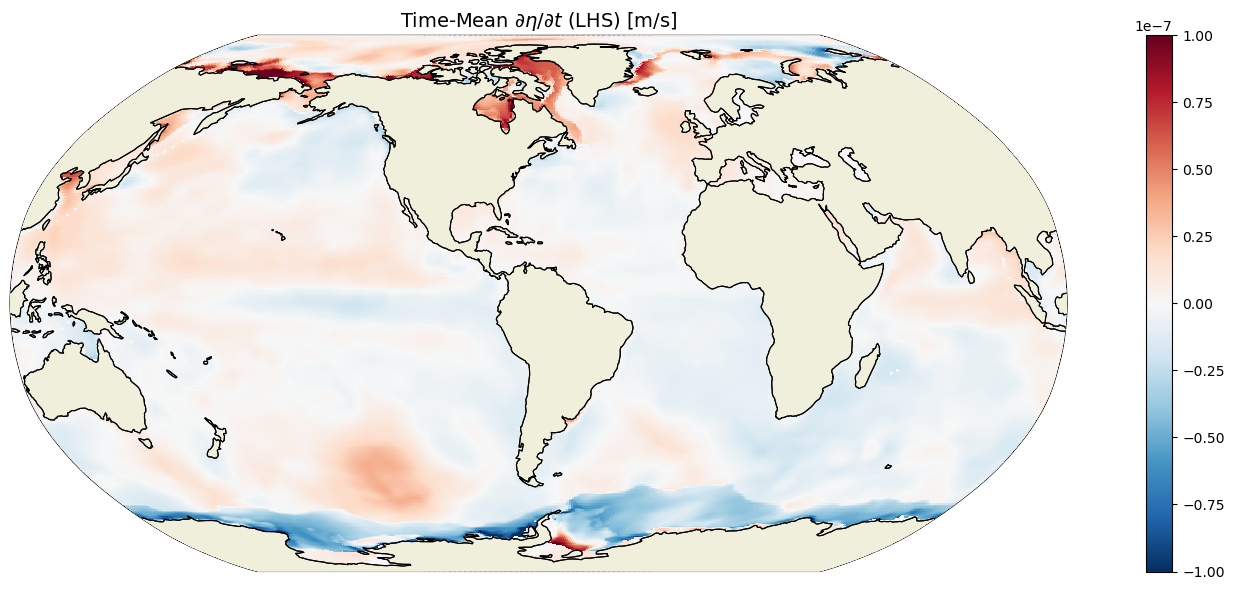

In [15]:
plt.figure(figsize=(16, 6))
ecco.plot_proj_to_latlon_grid(
    ecco_grid.XC, ecco_grid.YC,
    G_total_tendency_mean,
    show_colorbar=True,
    cmin=-1e-7, cmax=1e-7,
    cmap='RdBu_r',
    user_lon_0=-67,
    dx=map_dx, dy=map_dy
)
plt.title(r'Time-Mean $\partial \eta / \partial t$ (LHS) [m/s]', fontsize=14)
plt.tight_layout()
plt.show()

### Plot 2: Time-Mean RHS Components

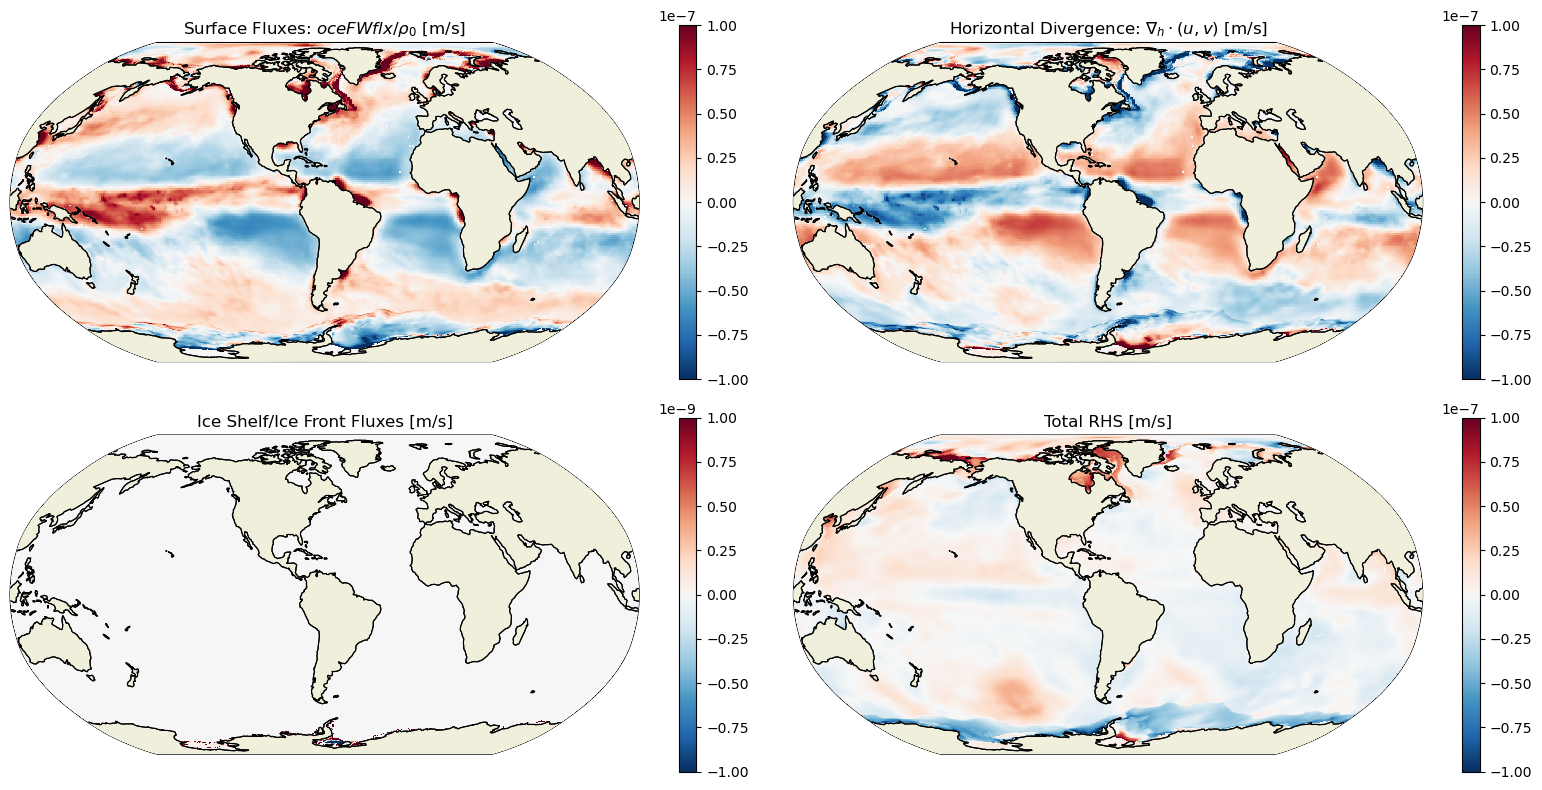

In [16]:
fig = plt.figure(figsize=(16,8))

# Surface fluxes
ecco.plot_proj_to_latlon_grid(
    ecco_grid.XC, ecco_grid.YC,
    G_surf_fluxes_mean,
    show_colorbar=True,
    cmin=-1e-7, cmax=1e-7,
    cmap='RdBu_r',
    user_lon_0=-67,
    subplot_grid=[2,2,1],
    dx=map_dx, dy=map_dy
)
plt.title(r'Surface Fluxes: $oceFWflx/\rho_0$ [m/s]', fontsize=12)

# Horizontal divergence
ecco.plot_proj_to_latlon_grid(
    ecco_grid.XC, ecco_grid.YC,
    G_vol_horiz_divergence_depth_integrated_mean,
    show_colorbar=True,
    cmin=-1e-7, cmax=1e-7,
    cmap='RdBu_r',
    user_lon_0=-67,
    subplot_grid=[2,2,2],
    dx=map_dx, dy=map_dy
)
plt.title(r'Horizontal Divergence: $\nabla_h \cdot (u,v)$ [m/s]', fontsize=12)

# Ice shelf/ice front fluxes (if available)
if has_SHIfwFlx or has_ICFfwFlx:
    ecco.plot_proj_to_latlon_grid(
        ecco_grid.XC, ecco_grid.YC,
        G_shiicf_fluxes_depth_integrated_mean,
        show_colorbar=True,
        cmin=-1e-9, cmax=1e-9,
        cmap='RdBu_r',
        user_lon_0=-67,
        subplot_grid=[2,2,3],        
        dx=map_dx, dy=map_dy
    )
    plt.title('Ice Shelf/Ice Front Fluxes [m/s]', fontsize=12)
# else:
#     plt.subplot(2, 2, 3)
#     plt.text(0.5, 0.5, 'No ice shelf/ice front fluxes', 
#              ha='center', va='center', fontsize=12)
#     plt.axis('off')

# Total RHS
RHS_total = (G_surf_fluxes_mean + 
             G_vol_horiz_divergence_depth_integrated_mean + 
             G_shiicf_fluxes_depth_integrated_mean)
ecco.plot_proj_to_latlon_grid(
    ecco_grid.XC, ecco_grid.YC,
    RHS_total,
    show_colorbar=True,
    cmin=-1e-7, cmax=1e-7,
    cmap='RdBu_r',
    user_lon_0=-67,
    subplot_grid=[2,2,4],     
    dx=map_dx, dy=map_dy
)
plt.title('Total RHS [m/s]', fontsize=12)

plt.tight_layout()
plt.show()

### Plot 3: Time-Mean Residual

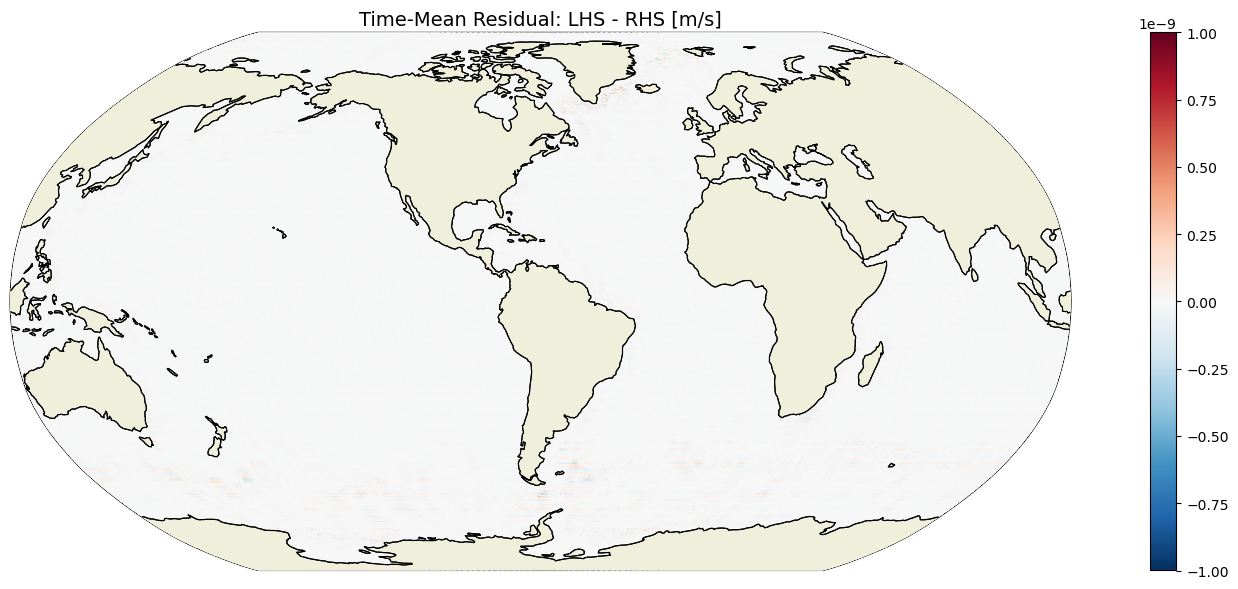


Residual statistics:
  Mean:  3.648e-16 m/s
  Std:   1.169e-11 m/s
  Max:   3.035e-10 m/s
  Min:   -2.671e-10 m/s


In [17]:
plt.figure(figsize=(16, 6))
ecco.plot_proj_to_latlon_grid(
    ecco_grid.XC, ecco_grid.YC,
    residual_mean,
    show_colorbar=True,
    cmin=-1e-9, cmax=1e-9,
    cmap='RdBu_r',
    user_lon_0=-67,
    dx=map_dx, dy=map_dy
)
plt.title(r'Time-Mean Residual: LHS - RHS [m/s]', fontsize=14)
plt.tight_layout()
plt.show()

print(f"\nResidual statistics:")
print(f"  Mean:  {float(residual_mean.mean()):.3e} m/s")
print(f"  Std:   {float(residual_mean.std()):.3e} m/s")
print(f"  Max:   {float(residual_mean.max()):.3e} m/s")
print(f"  Min:   {float(residual_mean.min()):.3e} m/s")

### Plot 4: Residual Histogram

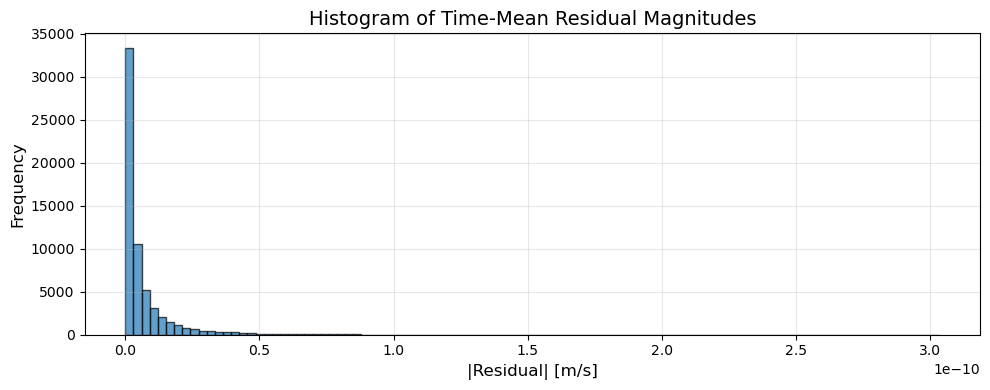


Histogram statistics:
  Median: 2.598e-12 m/s
  95th percentile: 2.848e-11 m/s
  99th percentile: 6.498e-11 m/s


In [18]:
# Histogram of time-mean residuals
tmp = np.abs(residual_mean.values).ravel()
tmp = tmp[~np.isnan(tmp)]  # Remove NaN values
tmp_nonzero = tmp[tmp > 0]

plt.figure(figsize=(10, 4))
plt.hist(tmp_nonzero, bins=100, edgecolor='black', alpha=0.7)
plt.xlabel('|Residual| [m/s]', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Histogram of Time-Mean Residual Magnitudes', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nHistogram statistics:")
print(f"  Median: {np.median(tmp_nonzero):.3e} m/s")
print(f"  95th percentile: {np.percentile(tmp_nonzero, 95):.3e} m/s")
print(f"  99th percentile: {np.percentile(tmp_nonzero, 99):.3e} m/s")

### Plot 5: Example Time Series at Selected Points

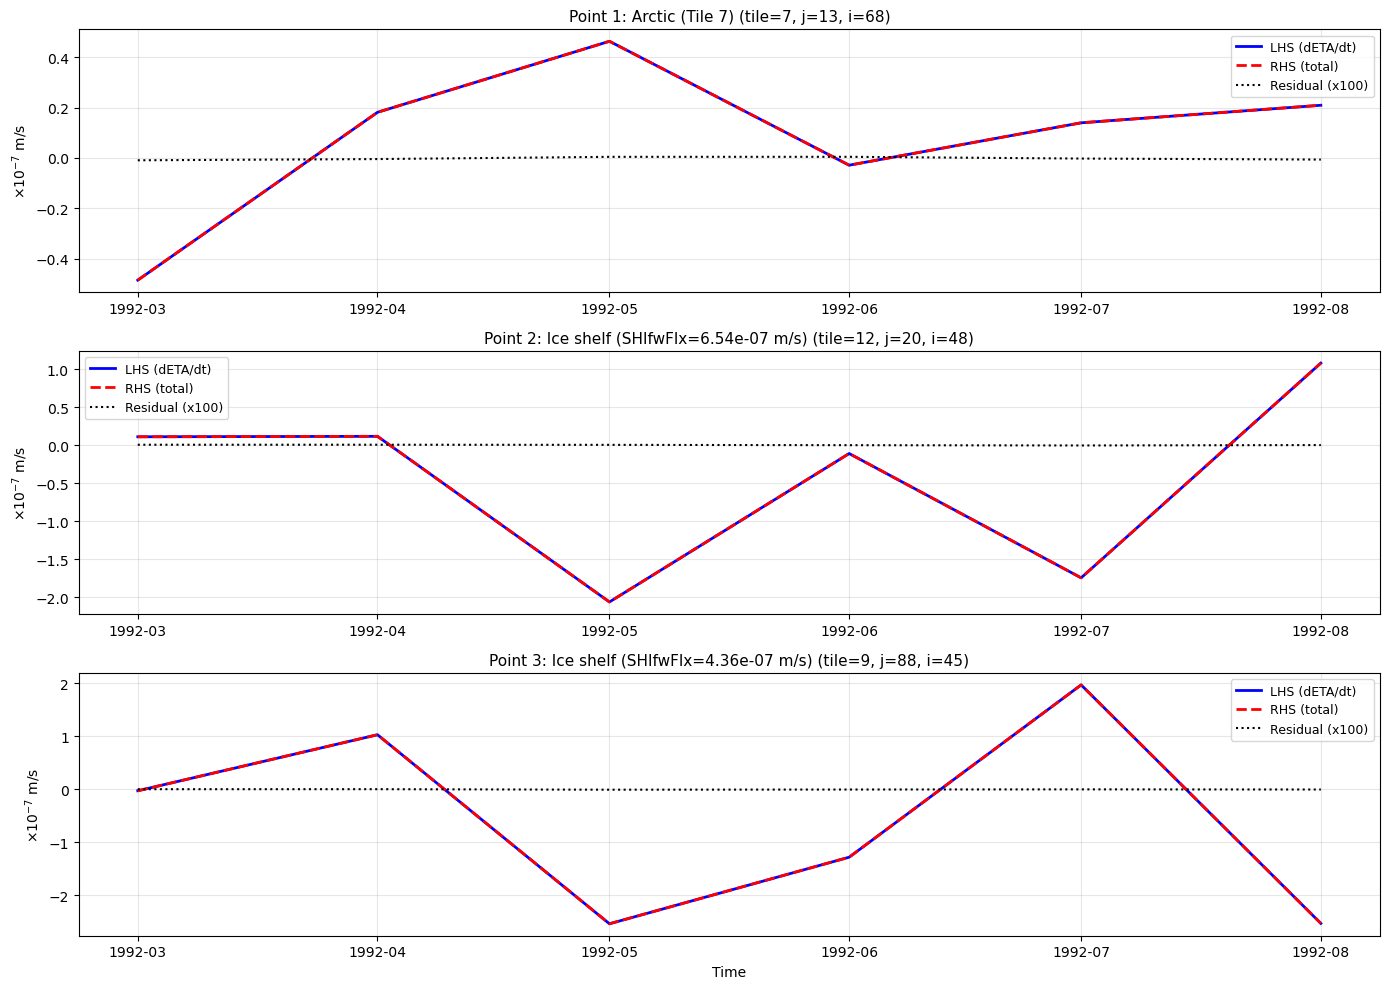

In [19]:
# Plot time series for first 3 test points
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

for idx in range(min(3, len(point_test_results))):
    result = point_test_results[idx]
    tile = result['tile']
    j = result['j']
    i = result['i']
    label = result['label']
    
    # Extract time series
    lhs_ts = G_total_tendency.isel(tile=tile, j=j, i=i)
    rhs_surf = G_surf_fluxes.isel(tile=tile, j=j, i=i)
    rhs_div = G_vol_horiz_divergence_depth_integrated.isel(tile=tile, j=j, i=i)
    rhs_ice = G_shiicf_fluxes_depth_integrated.isel(tile=tile, j=j, i=i)
    res_ts = residual.isel(tile=tile, j=j, i=i)
    
    rhs_total = rhs_surf + rhs_div + rhs_ice
    
    ax = axes[idx]
    ax.plot(lhs_ts.time, lhs_ts.values * 1e7, 'b-', linewidth=2, label='LHS (dETA/dt)')
    ax.plot(rhs_total.time, rhs_total.values * 1e7, 'r--', linewidth=2, label='RHS (total)')
    ax.plot(res_ts.time, res_ts.values * 1e9, 'k:', linewidth=1.5, label='Residual (x100)')
    
    ax.set_ylabel(r'$\times 10^{-7}$ m/s', fontsize=10)
    ax.set_title(f'Point {idx+1}: {label} (tile={tile}, j={j}, i={i})', fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best', fontsize=9)
    
    if idx == 2:
        ax.set_xlabel('Time', fontsize=10)

plt.tight_layout()
plt.show()

### Plot 6: Global Mean Time Series

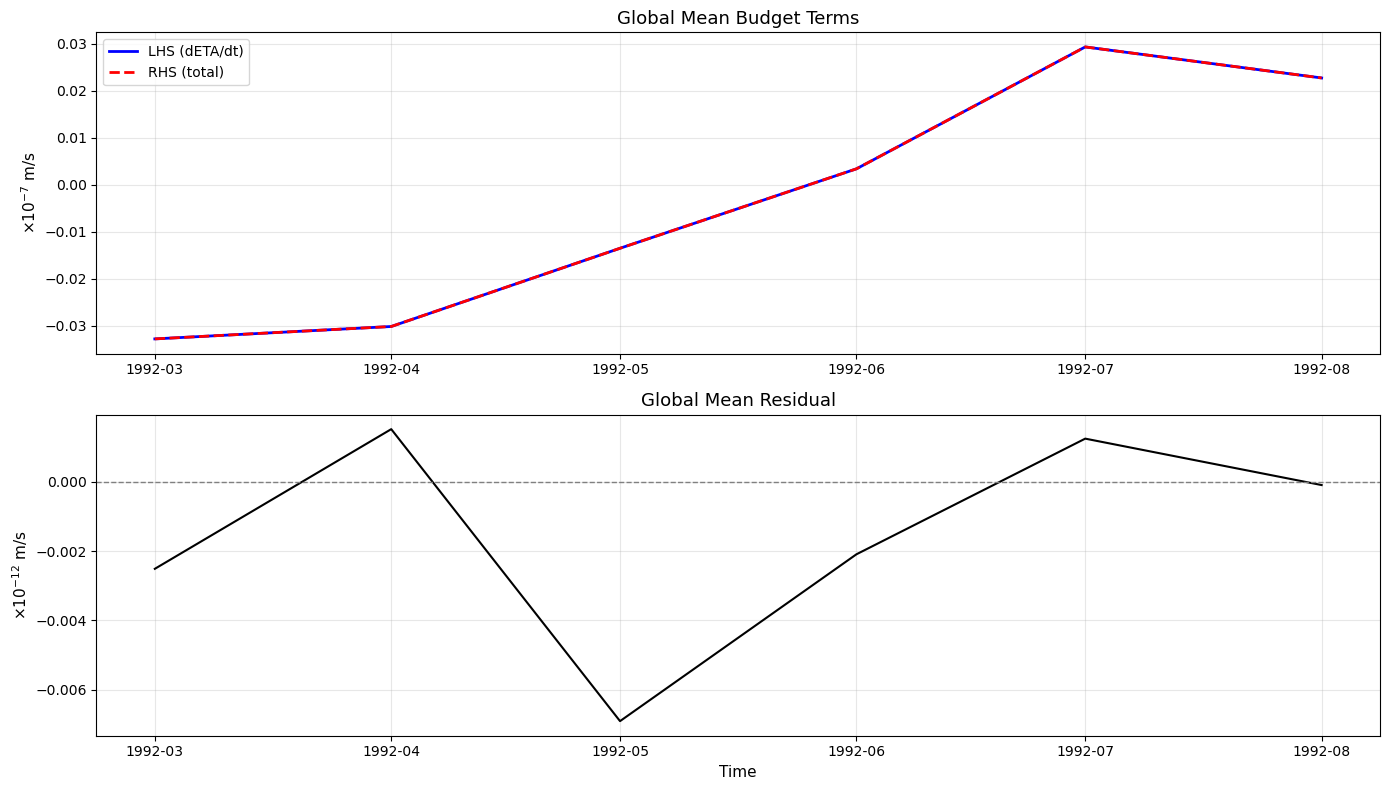


Global mean RMSE(residual): 3.221e-15 m/s
Global mean RMSE(LHS):      2.431e-09 m/s
Ratio:                      1.325e-06


In [20]:
# Calculate global means
area_masked = ecco_grid.rA.where(ecco_grid.hFacC.isel(k=0) > 0).compute()
area_sum = area_masked.sum(dim=('i', 'j', 'tile')).values

global_lhs_ts = (G_total_tendency * area_masked).sum(dim=('i', 'j', 'tile')) / area_sum
global_surf_ts = (G_surf_fluxes * area_masked).sum(dim=('i', 'j', 'tile')) / area_sum
global_div_ts = (G_vol_horiz_divergence_depth_integrated * area_masked).sum(dim=('i', 'j', 'tile')) / area_sum
global_ice_ts = (G_shiicf_fluxes_depth_integrated * area_masked).sum(dim=('i', 'j', 'tile')) / area_sum
global_residual_ts = (residual * area_masked).sum(dim=('i', 'j', 'tile')) / area_sum

global_rhs_ts = global_surf_ts + global_div_ts + global_ice_ts

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Top panel: LHS vs RHS
ax = axes[0]
ax.plot(global_lhs_ts.time, global_lhs_ts.values * 1e7, 'b-', 
        linewidth=2, label='LHS (dETA/dt)')
ax.plot(global_rhs_ts.time, global_rhs_ts.values * 1e7, 'r--', 
        linewidth=2, label='RHS (total)')
ax.set_ylabel(r'$\times 10^{-7}$ m/s', fontsize=11)
ax.set_title('Global Mean Budget Terms', fontsize=13)
ax.grid(True, alpha=0.3)
ax.legend(loc='best', fontsize=10)

# Bottom panel: Residual
ax = axes[1]
ax.plot(global_residual_ts.time, global_residual_ts.values * 1e12, 'k-', 
        linewidth=1.5)
ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.set_ylabel(r'$\times 10^{-12}$ m/s', fontsize=11)
ax.set_xlabel('Time', fontsize=11)
ax.set_title('Global Mean Residual', fontsize=13)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nGlobal mean RMSE(residual): {global_residual_rmse:.3e} m/s")
print(f"Global mean RMSE(LHS):      {global_lhs_rmse:.3e} m/s")
print(f"Ratio:                      {global_ratio:.3e}")

## 15. Export Results (Optional)

In [21]:
# Create results dictionary
results = {
    'overall_pass': overall_pass,
    'includes_ice_shelf_fluxes': has_SHIfwFlx or has_ICFfwFlx,
    'has_SHIfwFlx': has_SHIfwFlx,
    'has_ICFfwFlx': has_ICFfwFlx,
    'test_method': 'RMSE ratio',
    'global_test': {
        'pass': global_test_pass,
        'mean_residual': global_residual_mean,
        'std_residual': global_residual_std,
        'max_residual': global_residual_max,
        'rmse_residual': global_residual_rmse,
        'rmse_lhs': global_lhs_rmse,
        'ratio': global_ratio,
        'threshold': GLOBAL_THRESHOLD
    },
    'point_tests': {
        'n_passed': n_passed,
        'n_total': n_total,
        'all_pass': all_points_pass,
        'threshold': POINT_THRESHOLD,
        'n_arctic': sum([1 for r in point_test_results if 'Arctic' in r['label']]),
        'n_ice_shelf': sum([1 for r in point_test_results if 'Ice shelf' in r['label']]) if has_SHIfwFlx else 0,
        'n_random': sum([1 for r in point_test_results if r['label'] == 'Random']),
        'details': point_test_results
    },
    'column_tests': {
        'n_passed': n_col_passed,
        'n_total': n_col_total,
        'all_pass': all_columns_pass,
        'threshold': POINT_THRESHOLD,
        'details': column_test_results
    }
}

# Save to file (optional)
import json
output_file = 'volume_budget_test_results.json'
with open(output_file, 'w') as f:
    json.dump(results, f, indent=2)

print(f"\nResults saved to {output_file}")


Results saved to volume_budget_test_results.json
